<a href="https://colab.research.google.com/github/liza-zy/homeworks-ml-2025/blob/main/HW7_%D0%97%D1%8B%D1%80%D1%8F%D0%BD%D0%BE%D0%B2%D0%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Модуль 7. Финансовый аналитик

### Цель задания

Сегодня ты “Финансовый аналитик” - изучи и проанализируй внутренние финансы компании и финансовые показатели партнеров, конкурентов или стартапов, в которые компания хочет инвестировать.В частности: макроэкономические и микроэкономические условия наряду с фундаментальными показателями компании.Рекомендуй курс действий для руководства по покупке или продаже акций компании, исходя из ее общих показателей и перспектив. Проведи критический анализ архитектуры DataLake.

### Навыки

|Архитектура|Базы данных|Форматы данных|Инструменты|Коммуникации|
|-----------|-----------|--------------|-----------|------------|
|Событийная|GreenPlum|DeltaLake|Обучение  с подкреплением AsyncioRED Dagster Стандарт AsyncAPI Безопасность модели|Все отделы компании, банки|


### Условия

Можно пользоваться любыми языковыми моделями

###  Формат сдачи и отправка задания

Итоговый блокнот нужно разместить на GitLab либо на GitHub ("запушить" в любом формате .py или .ipynb)
и поделиться ссылкой на файл (убедившись, что видимости репозитория).

###  Сроки выполнения задания

Максимум одна неделя, сданные после истечения максимального срока  работы не проверяются.

###  Критерии оценивания

| Критерий                 | Вес | Описание                                                                                                                                                                                              |
|--------------------------|-----|----------------------------------------------------------|
| Выбор алгоритма          | 15% | Оценка уместности выбранного алгоритма для данной задачи.|
| Точность реализации      | 15% | Оценка корректности реализации алгоритма.                |
| Основная функциональность| 20% | Оценка степени выполнения основных требований задания.   |
| Обработка крайних случаев| 10% | Оценка кода по обработке граничных входных данных.       |
| Документация к коду      | 10% | Оценка ясности и полноты комментариев в коде.            |
| Объяснение результатов   | 10% | Оценка четкости объясненния результатов работы кода      |
| Стиль кода               | 10% | Оценка читаемости кода и соответствия PEP-8              |
| Анализ ошибок и отладка  | 10% | Оценка способности студента выявлять и исправлять ошибки |


**Максимальный балл за выполненную домашнюю работу: 10 баллов**

**Дополнительные условия оценки:**

Можно сдать работу через обычный Google Colab без начисления штрафных баллов и поделиться ссылкой на файл.

**Как будет проверяться:**

Работа будет проверяться преподавателем вручную в течение максимум одной недели.

### Задание №1

Подключи расширение RAPIDS cuDF командой ```%load_ext cudf.pandas``` и измерь ускорение работы pandas на графическом процессоре GPU


In [1]:
%%capture
# установка занимает 3 минуты
!git clone https://github.com/rapidsai/rapidsai-csp-utils.git
!python rapidsai-csp-utils/colab/pip-install.py
!pip install pandas gdown torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

In [2]:
import cudf
import pandas as pd
import gdown
url = "https://drive.google.com/uc?export=download&id=1HRajTCSQCaMJea_mrQKeSuI5BeLApgnT"
output = "Stock_Data.zip"
gdown.download(url, output)
!rm /content/all_stocks_5yr.csv -f
!unzip Stock_Data.zip
df = pd.read_csv("/content/all_stocks_5yr.csv", header = 0, sep = ',')
df.head(1)

Downloading...
From: https://drive.google.com/uc?export=download&id=1HRajTCSQCaMJea_mrQKeSuI5BeLApgnT
To: /content/Stock_Data.zip
100%|██████████| 10.1M/10.1M [00:00<00:00, 46.7MB/s]


Archive:  Stock_Data.zip
  inflating: all_stocks_5yr.csv      


,date,open,high,low,close,volume,Name
0,2013-02-08,15.07,15.12,14.63,14.75,8407500,AAL


In [3]:
big_df = pd.concat([df]*250,ignore_index=True);big_df.info() # увеличенный в 250 раз набор данных занял почти всю памть

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 154760000 entries, 0 to 154759999
Data columns (total 7 columns):
 #   Column  Dtype  
---  ------  -----  
 0   date    object 
 1   open    float64
 2   high    float64
 3   low     float64
 4   close   float64
 5   volume  int64  
 6   Name    object 
dtypes: float64(4), int64(1), object(2)
memory usage: 8.1+ GB


In [4]:
%%time

(big_df
 .groupby(["Name"])
 .agg({"close": "mean"})
 .rename(columns={"close": "mean_close_price"})
 .sort_values(["mean_close_price"], ascending=False)
) #обрабатываем 154 миллиона строк на CPU долго

CPU times: user 9.89 s, sys: 2.35 s, total: 12.2 s
Wall time: 14.8 s


,mean_close_price
Name,
PCLN,1312.873538
GOOG,725.403353
GOOGL,682.233847
AZO,619.703654
AMZN,576.880041
...,...
CHK,13.681326
AES,12.340048
RF,10.935608


In [2]:
%load_ext cudf.pandas

In [4]:
import cudf
import pandas as pd
import gdown
url = "https://drive.google.com/uc?export=download&id=1HRajTCSQCaMJea_mrQKeSuI5BeLApgnT"
output = "Stock_Data.zip"
gdown.download(url, output)
!rm /content/all_stocks_5yr.csv -f
!unzip Stock_Data.zip
df = pd.read_csv("/content/all_stocks_5yr.csv", header = 0, sep = ',')
df.head(1)

big_df = pd.concat([df]*250,ignore_index=True);big_df.info() # увеличенный в 250 раз набор данных занял почти всю памть


Downloading...
From: https://drive.google.com/uc?export=download&id=1HRajTCSQCaMJea_mrQKeSuI5BeLApgnT
To: /content/Stock_Data.zip
100%|██████████| 10.1M/10.1M [00:00<00:00, 39.2MB/s]


Archive:  Stock_Data.zip
  inflating: all_stocks_5yr.csv      
<class 'cudf.core.dataframe.DataFrame'>
RangeIndex: 154760000 entries, 0 to 154759999
Data columns (total 7 columns):
 #   Column  Dtype
---  ------  -----
 0   date    object
 1   open    float64
 2   high    float64
 3   low     float64
 4   close   float64
 5   volume  int64
 6   Name    object
dtypes: float64(4), int64(1), object(2)
memory usage: 8.9+ GB


In [5]:

%%time

(big_df
 .groupby(["Name"])
 .agg({"close": "mean"})
 .rename(columns={"close": "mean_close_price"})
 .sort_values(["mean_close_price"], ascending=False)
) #обрабатываем 154 миллиона строк на GPU быстро

CPU times: user 229 ms, sys: 486 ms, total: 715 ms
Wall time: 895 ms


,mean_close_price
Name,
PCLN,1312.873538
GOOG,725.403353
GOOGL,682.233847
AZO,619.703654
AMZN,576.880041
...,...
CHK,13.681326
AES,12.340048
RF,10.935608


Вычисление агрегирующей функции большого датафрейма на CPU занимает почти 10 секунд, в то время как вычисление той же функции на GPU занимает 0.2 секунды - примерно в 50 раз быстрее.

### Задание №2

Инжиниринг признаков — это создание новых признаков на основе существующих признаков. Создадим новый признак "день недели" из колонки "date". Подтверди или опровергни гипотезу о том, что день недели влияет на объём торгов (одной любой акции на свой выбор)

In [ ]:
df['timestamp'] = pd.to_datetime(df['date'])
df['day_of_week'] = df['timestamp'].dt.dayofweek  # Извлекаем день недели (0=понедельник, 6=воскресенье)
df.head(1) # датафрейм с новым признаком

,date,open,high,low,close,volume,Name,timestamp,day_of_week
0,2013-02-08,15.07,15.12,14.63,14.75,8407500,AAL,2013-02-08,4


In [ ]:
aapl = df[df['Name'] == 'AAPL']

# Средний объём по дням недели (0=понедельник, 6=воскресенье)
mean_by_day = aapl.groupby('day_of_week')['volume'].mean()
print(mean_by_day) # 5, тк торги только по будним дням

day_of_week
0    5.368932e+07
1    5.552923e+07
2    5.607552e+07
3    5.067358e+07
4    5.414573e+07
Name: volume, dtype: float64


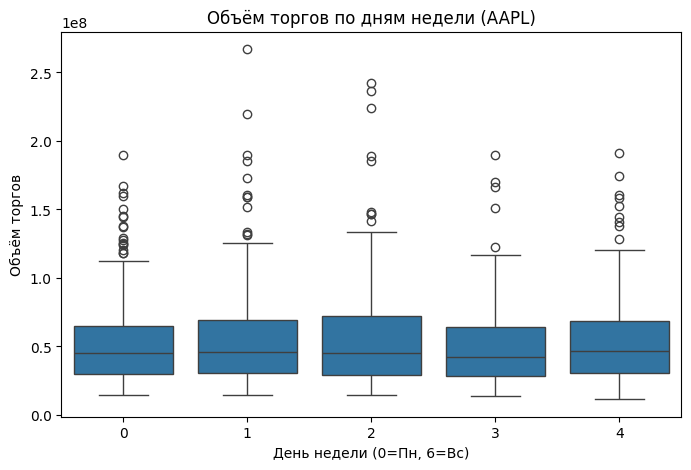

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
# Посмотрим распределение объемов по дням недели
plt.figure(figsize=(8,5))
sns.boxplot(x='day_of_week', y='volume', data=aapl)
plt.title('Объём торгов по дням недели (AAPL)')
plt.xlabel('День недели (0=Пн, 6=Вс)')
plt.ylabel('Объём торгов')
plt.show()

Сформулируем статистическую гипотезу:

H0 : средние объёмы торгов одинаковы для всех дней недели.
H1 : хотя бы в один день недели средний объём торгов отличается.

Для проверки применим однофакторный дисперсионный анализ. Для этого разделим данные по дням недели и используем f_oneway (ANOVA). Она вычисляет F-статистику для межгрупповых и внутригрупповых отличий и по ней определяет p-value.

In [ ]:
import scipy.stats as stats

groups = [aapl[aapl['day_of_week'] == i]['volume'].dropna() for i in range(5)]

f_stat, p_value = stats.f_oneway(*groups)

print(f"F-статистика: {f_stat:.3f}")
print(f"p-value: {p_value:.5f}")


F-статистика: 1.013
p-value: 0.39960


Поскольку p-value > 0.05, то мы не можем отвергнуть Н0 - средние объёмы торгов одинаковы для всех дней недели акции AAPL.

### Задание №3

Рассчитай технический индикатор "полосы Боллинджера" по имеющимся (хранящимся, статическим) данным

In [7]:
%%capture
!pip install TA-Lib  numpy==1.26.4


In [8]:
import talib
import numpy as np
from talib import MA_Type
import matplotlib.pyplot as plt

#print ("Список всех индикаторов\n","\n".join(talib.get_functions()))

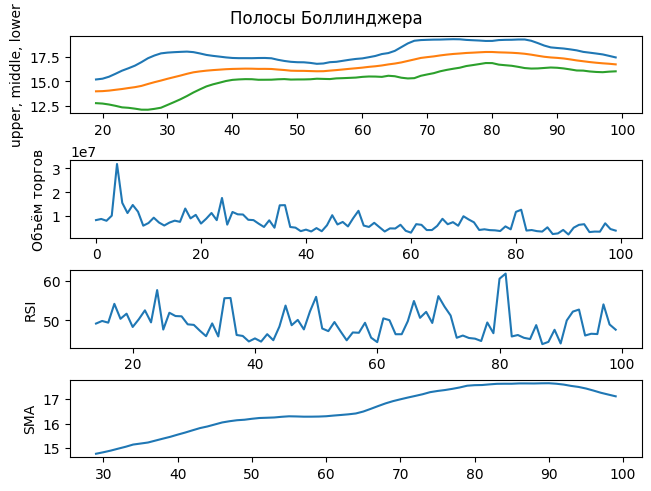

In [ ]:


df = df[:100]
rsi = talib.RSI(np.array(df["volume"], dtype=np.float64))
outputSMA = talib.SMA(np.array(df["close"], dtype=np.float64))
upper, middle, lower = talib.BBANDS(
    np.array(df["close"], dtype=np.float64),
    timeperiod=20,
    nbdevup=2,
    nbdevdn=2,
    matype=MA_Type.SMA
)
t = range(0, len(df["volume"]))

fig, axs = plt.subplots(4, 1, layout='constrained')
axs[0].plot(t, upper+0.03, t, middle,t,lower-0.03)
axs[0].set_ylabel('upper, middle, lower')
#axs[0].grid(True)
plt.suptitle("Полосы Боллинджера")
axs[1].plot(range(0, len(df["volume"])),df["volume"])
axs[1].set_ylabel('Объём торгов')
axs[2].plot(range(0, len(df["volume"])),rsi)
axs[2].set_ylabel('RSI')
axs[3].plot(range(0, len(df["volume"])),outputSMA)
axs[3].set_ylabel('SMA')
plt.show()

### Задание №4

Рассчитай технический индикатор "скользящая средняя" по потоковым (только полученным, свежим) данным используя  Streaming API

In [9]:
%%capture
!pip install 'python-engineio==3.14.2'
!pip install 'python-socketio==4.3.1'

In [10]:
from talib import stream

close = np.array(df["close"], dtype=np.float64)

output = talib.SMA(close) # the Function API для статических данных
latest = stream.SMA(close) # the Streaming API <- используй потоковый API
print ("статические данные ",output[-1], ", потоковые данные ", latest)

статические данные  75.33466666666656 , потоковые данные  75.33466666666665


In [11]:
import socketio
import time

# standard Python
sio = socketio.Client()

@sio.event
def connect():
    print("I'm connected!")
    sio.emit('login', {'userKey': 'wsfQsXX90onvUpylWgzQ'})

@sio.event
def connect_error():
    print("The connection failed!")

@sio.event
def message(data):
    print('I received a message!')

@sio.on('handshake')
def on_message(data):
    print('HandShake', data)
    sio.emit('symbolSub', {'symbol': 'EURUSD'})

@sio.event
def disconnect():
    print('disconnected from server')

In [13]:
from collections import deque

SMA_PERIOD = 20 # число значений для усреднения
_mid_values = deque(maxlen=SMA_PERIOD) # буфер последних цен


def _parse_mid(line: str) -> float:
    # Формат обычно: SYMBOL BID ASK MID DATETIME, поэтому берем 4й элемент
    parts = str(line).split()
    if len(parts) < 5:
        raise ValueError(f"Bad price payload: {line}")
    return float(parts[3])


@sio.on('price')
def on_message(data):
    # напиши здесь код, использующий потоковый API stream.SMA
    try:
        mid = _parse_mid(data)
        _mid_values.append(mid)

        # talib.stream.SMA возвращает последнее значение SMA для переданного массива
        sma_last = stream.SMA(np.array(_mid_values, dtype=np.float64), timeperiod=SMA_PERIOD)

        if sma_last == sma_last:  # проверка на NaN
            print(f"SMA{SMA_PERIOD} (mid) = {sma_last:.6f}")
        else:
            needed = max(0, SMA_PERIOD - len(_mid_values))
            print(f"SMA{SMA_PERIOD}: недостаточно данных, ещё {needed} тик(а)")
    except Exception as e:
        print("Ошибка обработки:", e)

    print('Price Data', data)

In [14]:
sio.connect('https://marketdata.tradermade.com')
time.sleep(30)
sio.disconnect()
time.sleep(3) #не получается по заданному ключу получить доступ к данным - только подключение
# к сайту

I'm connected!


Не получается установить соединение с сайтом - только подключение. Вероятно ключ недействительный, при этом при регистрации необходимо отправить письмо на адрес, что не получается сделать ( какая-то ошибка внутри почты)

### Задание №5

Современный оркестратор Dagster.io даёт возможность **реактивно** запускать следующий этап конвейера данных (при изменении данных предыдущего этапа) используя [Сенсор](https://docs.dagster.io/guides/automate/asset-sensors).

Подключи Сенсор к функции daily_sales_data_sensor, реагирующий на изменение "daily_sales_data" и запускающий обновление weekly_report

In [ ]:
%%capture
!pip install dagster dagster-dg-cli

In [ ]:
import dagster as dg
from datetime import datetime

@dg.asset(description="ежедневный отчёт по стоимости чистых активов ПИФа")
def daily_sales_data(context: dg.AssetExecutionContext):
    context.log.info("Запускаю ежедневный отчёт СЧА")
    yield dg.MaterializeResult(value=df[-1:]["close"].to_list(),metadata={"отчёт СЧА на дату": datetime.now().isoformat()})


@dg.asset(description="еженедельный отчёт по стоимости чистых активов ПИФа")
def weekly_report(context: dg.AssetExecutionContext):
    context.log.info("Еженедельный отчёт СЧА готов")
    yield dg.MaterializeResult(metadata={"Еженедельный отчёт СЧА на дату": datetime.now().isoformat()})


my_job = dg.define_asset_job("Обновление еженедельного отчёта СЧА", [weekly_report])

#нужно подключить Сенсор к этой функции
def daily_sales_data_sensor(context: dg.SensorEvaluationContext, asset_event):
    context.log.info("Обнаружено обновление daily_sales_data, запускаю weekly_report")
    yield dg.RunRequest(
        run_key=f"run_{asset_event.event_log_entry.dagster_event.timestamp}",
        run_config={}
    )

print([_ for _ in daily_sales_data(None)],
      "\n",
[_ for _ in weekly_report(None)])

2025-10-26 17:12:41 +0000 - dagster - INFO - system - Запускаю ежедневный отчёт СЧА
2025-10-26 17:12:41 +0000 - dagster - INFO - system - Еженедельный отчёт СЧА готов


[MaterializeResult(asset_key=None, metadata={'отчёт СЧА на дату': '2025-10-26T17:12:41.820689'}, check_results=[], data_version=None, tags=None, value=[16.43])] 
 [MaterializeResult(asset_key=None, metadata={'Еженедельный отчёт СЧА на дату': '2025-10-26T17:12:41.882247'}, check_results=[], data_version=None, tags=None, value=<class 'dagster._core.definitions.utils.NoValueSentinel'>)]
